# Phần 3: Kiểm định giả thuyết thống kê (Hypothesis Testing) trên tập dữ liệu Kim Cương
**Dữ liệu sử dụng:** `data/processed/cleaned_diamonds.csv` do nhóm bàn giao từ Phần 1; nguồn gốc [Diamonds trên Kaggle](https://www.kaggle.com/datasets/shivam2503/diamonds).  
**Mức ý nghĩa toàn cục:** $\alpha = 0.05$.  
**Quy ước kiểm định:** Tất cả các kiểm định đều sử dụng kiểm định hai phía (*two-sided / two-tailed*), trừ khi có giả thuyết định hướng xác định trước.

Notebook này tiếp nối trực tiếp phân tích phân phối ở **Phần 2** (vốn đã chỉ ra rằng `price` có phân phối lệch phải mạnh và có ngoại lai hợp lệ). Chúng ta sẽ giải quyết hai câu hỏi nghiên cứu thực nghiệm:
1. **Câu hỏi 1:** Giá kim cương (`price`) có khác biệt có ý nghĩa thống kê theo chất lượng giác cắt (`cut`) không? So sánh cụ thể giữa hai nhóm giác cắt cao cấp `Premium` và `Ideal`?
2. **Câu hỏi 2:** Chất lượng giác cắt (`cut`) có mối liên hệ độc lập hay phụ thuộc với màu sắc (`color`) của kim cương?

**Nguyên tắc phương pháp luận:**
- Đọc dữ liệu chung từ `data/processed/cleaned_diamonds.csv`, tuyệt đối không làm biến dạng dữ liệu gốc.
- Sửa lỗi đường dẫn `../data/processed/.csv` (trước đó thiếu tên file) bằng cơ chế tự nhận diện đường dẫn linh hoạt giữa thư mục gốc repo và thư mục `notebooks/`.
- Luôn kiểm tra các điều kiện giả định trước khi chạy kiểm định; áp dụng các phương pháp hiệu chỉnh hoặc kiểm định vững (*robust methods*) khi điều kiện bị vi phạm (như Welch's ANOVA, Welch's t-test, Games-Howell).
- Báo cáo đầy đủ: Thống kê kiểm định, bậc tự do, $p$-value, mức ý nghĩa $\alpha$, kích thước ảnh hưởng (*effect size: Cohen's d, $\eta^2$, Cramér's V*), khoảng tin cậy 95% (*95% CI*), và phân tích hiện tượng biến gây nhiễu (*Confounding / Simpson's Paradox*).
- Xuất toàn bộ bảng số liệu và biểu đồ chuẩn vào thư mục `figures/part3_hypothesis/`.


In [1]:
from pathlib import Path
import hashlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import studentized_range
from IPython.display import display, Markdown

# Cấu hình mức ý nghĩa và hằng số toàn cục
ALPHA = 0.05
SEED = 42
np.random.seed(SEED)

CUT_ORDER = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

# Xử lý đường dẫn linh hoạt (sửa triệt để lỗi đường dẫn ../data/processed/.csv bị thiếu tên file)
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'data' / 'processed' / 'cleaned_diamonds.csv').is_file() else cwd.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_diamonds.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'part3_hypothesis'

if not DATA_PATH.is_file():
    raise FileNotFoundError(f'Không tìm thấy tập dữ liệu tại: {DATA_PATH}. Vui lòng kiểm tra lại cấu trúc repo.')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Thiết lập chuẩn style biểu đồ thống nhất
sns.set_theme(style='whitegrid', font='DejaVu Sans', font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda val: f'{val:,.4f}')

# Nạp dữ liệu và lưu bản sao đối chứng
df = pd.read_csv(DATA_PATH)
df_original = df.copy(deep=True)
saved_files = []

source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print(f'Môi trường Python: {sys.executable}')
print(f'Tập dữ liệu đầu vào: {DATA_PATH}')
print(f'Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'Mã băm SHA-256 dữ liệu: {source_sha256}')
display(df.head())


Môi trường Python: D:\PROJECT-Mid-final\Diamonds-analysis\venv\Scripts\python.exe
Tập dữ liệu đầu vào: D:\PROJECT-Mid-final\Diamonds-analysis\data\processed\cleaned_diamonds.csv
Kích thước dữ liệu: 53,772 dòng × 10 cột
Mã băm SHA-256 dữ liệu: 356dd4512d6a2a8c9b62c4b200983daa4c03048401d0991b9778f9ac4cae8237
   carat      cut color clarity   depth   table  price      x      y      z
0 0.2300    Ideal     E     SI2 61.5000 55.0000    326 3.9500 3.9800 2.4300
1 0.2100  Premium     E     SI1 59.8000 61.0000    326 3.8900 3.8400 2.3100
2 0.2300     Good     E     VS1 56.9000 65.0000    327 4.0500 4.0700 2.3100
3 0.2900  Premium     I     VS2 62.4000 58.0000    334 4.2000 4.2300 2.6300
4 0.3100     Good     J     SI2 63.3000 58.0000    335 4.3400 4.3500 2.7500


## 3.1. Kiểm tra tính toàn vẹn của dữ liệu đầu vào
Trước khi tiến hành kiểm định, chúng ta xác thực:
1. Các biến mục tiêu của Phần 3 (`price`, `cut`, `color`) và biến phụ trợ (`carat`) có đầy đủ không.
2. Dữ liệu có chứa giá trị thiếu (`NaN`), vô hạn, hay các giá trị phi lý (`<= 0`) hay không.
3. Các mức phân loại của `cut` và `color` có đúng với bảng mã chuẩn không.


In [2]:
# Kiểm tra các cột bắt buộc
required_cols = {'price', 'cut', 'color', 'carat'}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f'Thiếu các cột bắt buộc: {missing_cols}')

if df.empty:
    raise ValueError('Tập dữ liệu rỗng!')

validation_records = [
    {'Tiêu chí kiểm tra': 'Tổng số quan sát (N)', 'Kết quả': f"{len(df):,}"},
    {'Tiêu chí kiểm tra': 'Số cột dữ liệu', 'Kết quả': df.shape[1]},
    {'Tiêu chí kiểm tra': 'Giá trị thiếu trong price/cut/color', 'Kết quả': int(df[['price', 'cut', 'color']].isna().sum().sum())},
    {'Tiêu chí kiểm tra': 'Giá trị price <= 0 hoặc không hữu hạn', 'Kết quả': int((df['price'] <= 0).sum() + (~np.isfinite(df['price'])).sum())},
    {'Tiêu chí kiểm tra': 'Các mức chất lượng giác cắt (cut)', 'Kết quả': ', '.join(df['cut'].unique())},
    {'Tiêu chí kiểm tra': 'Các mức màu sắc (color)', 'Kết quả': ', '.join(sorted(df['color'].unique()))},
]
validation_table = pd.DataFrame(validation_records)
display(validation_table)

if df[['price', 'cut', 'color']].isna().any().any():
    raise ValueError('Phát hiện giá trị thiếu trong các biến kiểm định!')

print('Dữ liệu hợp lệ 100%. Tiếp tục quy trình phân tích.')


                       Tiêu chí kiểm tra  \
0                   Tổng số quan sát (N)   
1                         Số cột dữ liệu   
2    Giá trị thiếu trong price/cut/color   
3  Giá trị price <= 0 hoặc không hữu hạn   
4      Các mức chất lượng giác cắt (cut)   
5                Các mức màu sắc (color)   

                                 Kết quả  
0                                 53,772  
1                                     10  
2                                      0  
3                                      0  
4  Ideal, Premium, Good, Very Good, Fair  
5                    D, E, F, G, H, I, J  
Dữ liệu hợp lệ 100%. Tiếp tục quy trình phân tích.


## 3.2. Khảo sát phân phối và thống kê mô tả trước khi kiểm định
Trong Phần 2, ta đã chứng minh biến `price` lệch phải mạnh (*Skewness* = 1.62) và có nhiều giá trị ngoại lai ở phân khúc giá cao.  
Dưới đây, ta lập bảng thống kê mô tả chi tiết của `price` cho từng nhóm `cut` và trực quan hóa phân phối qua Boxplot và KDE. Điều này giúp phát hiện trước sự vi phạm về tính chuẩn và tính đồng nhất phương sai.


BẢNG THỐNG KÊ MÔ TẢ GIÁ KIM CƯƠNG (PRICE) THEO NHÓM GIÁC CẮT (CUT):
               N       Mean        Std     Median        Q25        Q75  \
cut                                                                       
Fair        1597 4,340.6775 3,540.8590 3,282.0000 2,049.0000 5,185.0000   
Good        4888 3,916.2791 3,665.9239 3,038.0000 1,143.2500 5,015.7500   
Very Good  12067 3,981.0868 3,935.0826 2,647.0000   912.0000 5,371.5000   
Premium    13736 4,578.3583 4,342.4042 3,177.5000 1,046.0000 6,290.0000   
Ideal      21484 3,462.2127 3,810.6964 1,813.0000   878.0000 4,685.2500   

                 IQR  Min    Max  Skewness  Tỷ lệ (%)  
cut                                                    
Fair      3,136.0000  337  18574    1.7878     2.9700  
Good      3,872.5000  327  18707    1.7229     9.0900  
Very Good 4,459.5000  336  18818    1.5960    22.4400  
Premium   5,244.0000  326  18823    1.3346    25.5400  
Ideal     3,807.2500  326  18806    1.8330    39.9500  
Nhận xét sơ bộ

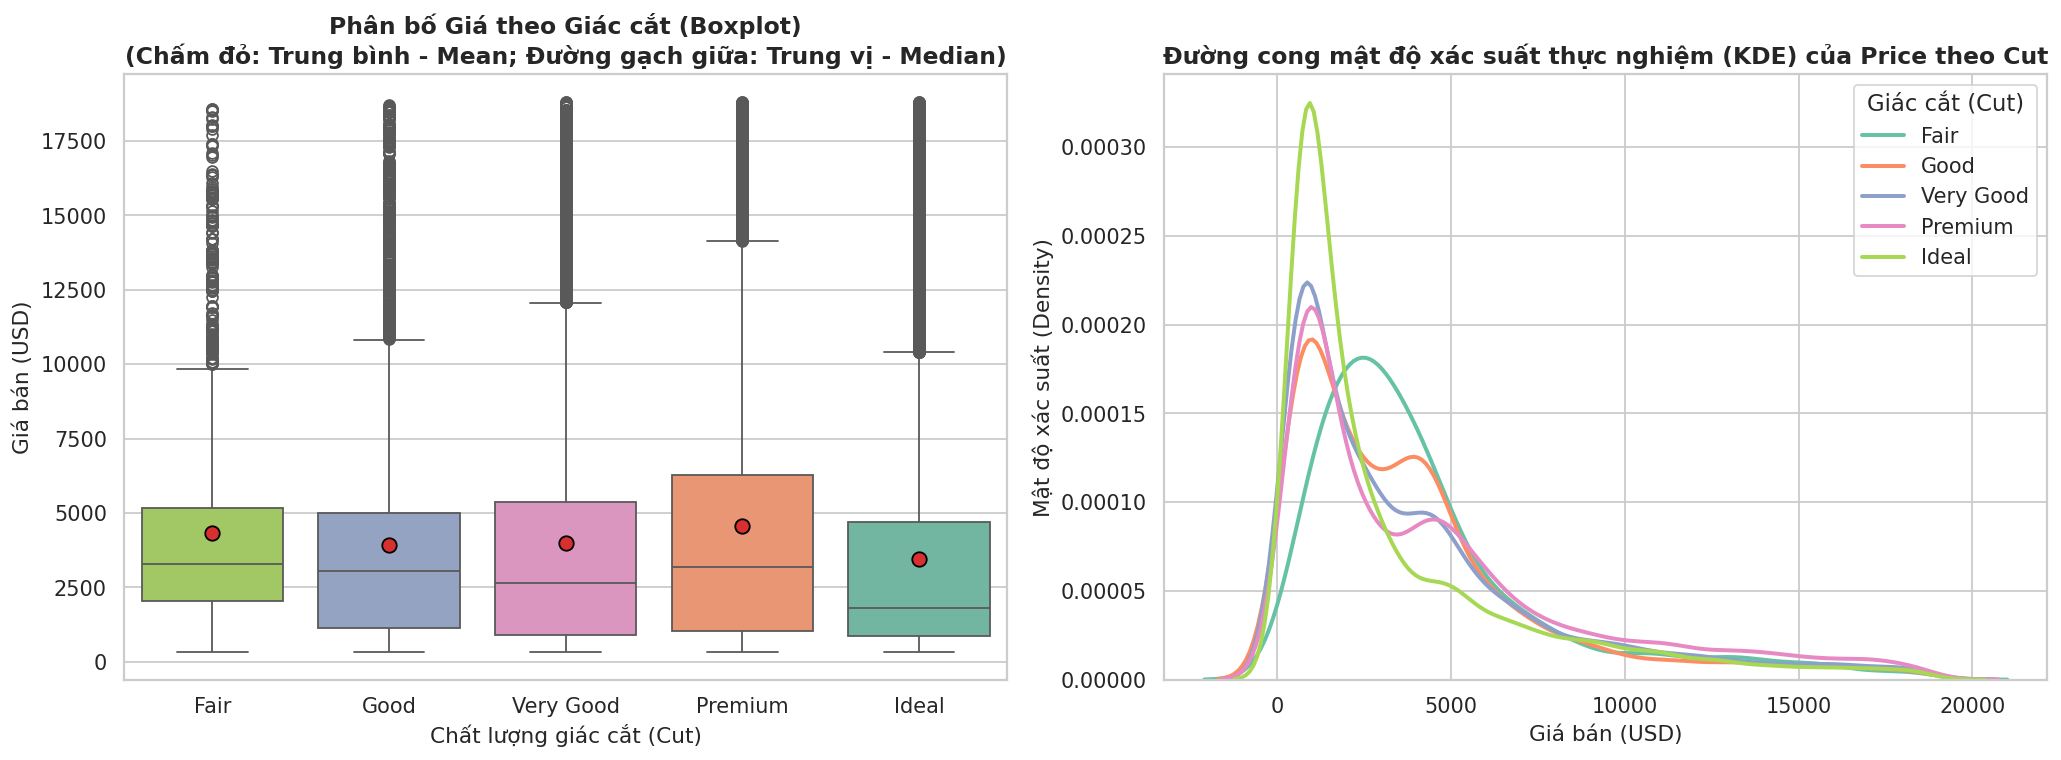

In [3]:
# Bảng thống kê mô tả chi tiết của Price theo Cut
desc_cut = df.groupby('cut')['price'].agg(
    N='count',
    Mean='mean',
    Std='std',
    Median='median',
    Q25=lambda x: np.percentile(x, 25),
    Q75=lambda x: np.percentile(x, 75),
    IQR=lambda x: np.percentile(x, 75) - np.percentile(x, 25),
    Min='min',
    Max='max',
    Skewness=lambda x: stats.skew(x)
).reindex(CUT_ORDER)

# Tính tỷ lệ phần trăm số quan sát
desc_cut['Tỷ lệ (%)'] = (desc_cut['N'] / len(df) * 100).round(2)

print('BẢNG THỐNG KÊ MÔ TẢ GIÁ KIM CƯƠNG (PRICE) THEO NHÓM GIÁC CẮT (CUT):')
display(desc_cut)

# Lưu bảng thống kê vào thư mục figures/part3_hypothesis/
desc_export_path = FIGURES_DIR / 'descriptive_price_by_cut.csv'
desc_cut.to_csv(desc_export_path, encoding='utf-8-sig')
saved_files.append(desc_export_path)

# Trực quan hóa phân phối
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot có hiển thị điểm Mean màu đỏ
palette_colors = sns.color_palette('Set2', len(CUT_ORDER))
sns.boxplot(
    data=df, x='cut', y='price', order=CUT_ORDER, ax=axes[0],
    palette=palette_colors, hue='cut', legend=False, showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': '#d63031', 'markeredgecolor': 'black', 'markersize': '8'}
)
axes[0].set_title('Phân bố Giá theo Giác cắt (Boxplot)\n(Chấm đỏ: Trung bình - Mean; Đường gạch giữa: Trung vị - Median)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chất lượng giác cắt (Cut)', fontsize=12)
axes[0].set_ylabel('Giá bán (USD)', fontsize=12)

# 2. KDE Plot
for idx, c in enumerate(CUT_ORDER):
    sns.kdeplot(df[df['cut'] == c]['price'], ax=axes[1], label=c, color=palette_colors[idx], linewidth=2.2)
axes[1].set_title('Đường cong mật độ xác suất thực nghiệm (KDE) của Price theo Cut', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá bán (USD)', fontsize=12)
axes[1].set_ylabel('Mật độ xác suất (Density)', fontsize=12)
axes[1].legend(title='Giác cắt (Cut)')

plt.tight_layout()
fig1_path = FIGURES_DIR / '01_price_distribution_by_cut.png'
fig.savefig(fig1_path, dpi=300)
saved_files.append(fig1_path)
plt.show()

print('Nhận xét sơ bộ từ biểu đồ:')
print('1. Cả 5 nhóm đều có phân phối lệch phải rõ rệt với đuôi dài phía trên (Skewness > 1.4).')
print('2. Độ lệch chuẩn (Std) và biên độ biến động giữa các nhóm khác biệt đáng kể (Fair: 3,541 USD vs Premium: 4,342 USD).')
print('3. Bất ngờ: Nhóm Ideal (giác cắt lý tưởng) có Mean ($3,462.21) và Median ($1,809.50) thấp hơn đáng kể so với Premium và Fair!')


## 3.3. Phần a — Khung lý thuyết ba phép kiểm định thống kê

Để trả lời các câu hỏi nghiên cứu một cách khoa học, chúng ta trình bày ba phép kiểm định theo cùng một khuôn mẫu chuẩn hóa:

---

### 1. Kiểm định t hai mẫu độc lập (Two-Sample t-test & Welch's t-test)
- **Mục đích:** So sánh giá trị trung bình của một biến số định lượng giữa hai nhóm độc lập.
- **Loại biến:** 1 biến phụ thuộc định lượng (*Continuous*) và 1 biến phân loại 2 mức (*Binary Categorical*).
- **Cặp giả thuyết:**
  - $H_0: \mu_1 = \mu_2$ (Giá trị trung bình của hai tổng thể bằng nhau).
  - $H_1: \mu_1 
eq \mu_2$ (Giá trị trung bình của hai tổng thể khác nhau — kiểm định hai phía).
- **Điều kiện giả định:**
  1. Các quan sát độc lập nhau.
  2. Dữ liệu trong mỗi nhóm tuân theo phân phối chuẩn (hoặc cỡ mẫu đủ lớn theo Định lý Giới hạn Trung tâm CLT để đảm bảo trung bình mẫu xấp xỉ chuẩn).
  3. Phương sai giữa hai nhóm bằng nhau (Homoscedasticity).
  - *Lưu ý quan trọng:* Đối với dữ liệu giá kim cương, do phương sai giữa các nhóm không bằng nhau, ta **ưu tiên sử dụng Welch’s t-test**. Welch’s t-test hiệu chỉnh bậc tự do theo công thức Welch–Satterthwaite và không yêu cầu giả định phương sai bằng nhau.
- **Cách diễn giải p-value & Kích thước ảnh hưởng:**
  - $p < 0.05$: Bác bỏ $H_0$, có bằng chứng thống kê về sự khác biệt giữa hai trung bình nhóm.
  - Tuy nhiên, $p$-value không cho biết mức độ khác biệt lớn hay nhỏ. Do đó, bắt buộc phải báo cáo:
    + Chênh lệch trung bình kèm **Khoảng tin cậy 95% (95% CI)**.
    + Kích thước ảnh hưởng **Cohen's d**: $d = rac{ar{X}_1 - ar{X}_2}{s_{\text{pooled}}}$ ($d \approx 0.2$: nhỏ, $0.5$: trung bình, $0.8$: lớn).

---

### 2. Kiểm định Chi bình phương về tính độc lập (Chi-square Test of Independence)
- **Mục đích:** Kiểm tra xem có mối liên hệ thống kê giữa hai biến phân loại bằng cách phân tích bảng tần số chéo (*Contingency Table*).
- **Loại biến:** 2 biến định danh hoặc thứ bậc (*Categorical variables*).
- **Cặp giả thuyết:**
  - $H_0$: Hai biến độc lập với nhau (tỷ lệ phân bố của biến này không phụ thuộc vào biến kia).
  - $H_1$: Hai biến có mối liên hệ phụ thuộc với nhau.
- **Điều kiện giả định:**
  1. Mẫu ngẫu nhiên độc lập.
  2. Bảng tần số phải có tần số kỳ vọng (*Expected frequency*) $E_{ij} \ge 5$ ở ít nhất 80% số ô và không có ô nào có $E_{ij} < 1$. Nếu có ô quá thưa, cần cân nhắc gộp nhóm.
- **Cách diễn giải p-value & Kích thước ảnh hưởng:**
  - $p < 0.05$: Bác bỏ $H_0$, hai biến có liên hệ thống kê.
  - Nhấn mạnh: Với cỡ mẫu rất lớn ($N > 50,000$), kiểm định Chi-square có lực thống kê cực mạnh, dễ dàng bác bỏ $H_0$ ngay cả với độ lệch rất nhỏ. Vì vậy, bắt buộc phải báo cáo chỉ số **Cramér’s V** để đo độ mạnh thực tế của mối liên hệ:
    $$V = \sqrt{\frac{\chi^2}{N \times (\min(r, c) - 1)}}$$
    ($V < 0.1$: liên hệ cực kỳ yếu/không đáng kể; $0.1 - 0.3$: yếu; $0.3 - 0.5$: trung bình; $> 0.5$: mạnh).

---

### 3. Phân tích phương sai một yếu tố (One-way ANOVA & Welch ANOVA)
- **Mục đích:** So sánh giá trị trung bình của một biến định lượng giữa từ ba nhóm độc lập trở lên.
- **Loại biến:** 1 biến phụ thuộc định lượng (*Continuous*) và 1 biến độc lập phân loại $\ge 3$ nhóm (*Factor/Categorical*).
- **Cặp giả thuyết:**
  - $H_0: \mu_1 = \mu_2 = \dots = \mu_k$ (Mọi trung bình nhóm đều bằng nhau).
  - $H_1$: Tồn tại ít nhất một nhóm có giá trị trung bình khác với các nhóm còn lại.
- **Điều kiện giả định:**
  1. Các quan sát độc lập nhau.
  2. Phần dư tuân theo phân phối chuẩn trong từng nhóm (vững với $N$ lớn nhờ CLT).
  3. Phương sai giữa các nhóm bằng nhau (Homoscedasticity, kiểm tra bằng Levene test). Nếu vi phạm, sử dụng **Welch's ANOVA**.
- **Cách diễn giải p-value, Phân tích hậu kiểm & Kích thước ảnh hưởng:**
  - Nếu ANOVA có ý nghĩa ($p < 0.05$), ANOVA chỉ cho biết "có sự khác biệt ở đâu đó" chứ không chỉ ra cặp nhóm cụ thể nào khác nhau. Vì vậy cần thực hiện **phân tích hậu kiểm (Post-hoc test)**:
    + Khi phương sai bằng nhau: Dùng **Tukey HSD**.
    + Khi phương sai không bằng nhau: Dùng **Games–Howell**.
  - Báo cáo kích thước ảnh hưởng **Eta-squared ($\eta^2$)**: Tỷ lệ phần trăm tổng biến thiên của biến phụ thuộc được giải thích bởi yếu tố phân nhóm.

---

> **Nguyên tắc cốt lõi xuyên suốt:**  
> Giá trị $p$-value nhỏ hơn $0.05$ chỉ là bằng chứng bác bỏ $H_0$; nó **không** đo lường độ lớn của sự khác biệt. Do đó, việc báo cáo kích thước ảnh hưởng (*Effect size*) và khoảng tin cậy (*Confidence interval*) là bắt buộc để đánh giá ý nghĩa thực tiễn (*practical significance*).


## 3.4. Kiểm tra điều kiện giả định và Phương án thay thế

Trước khi thực hiện các phép kiểm định cho Câu hỏi 1 và Câu hỏi 2, chúng ta kiểm tra nghiêm ngặt các giả định:
1. **Tính độc lập:** Mỗi dòng tương ứng một viên kim cương riêng lẻ, được đo đạc và định giá độc lập.
2. **Tính chuẩn và Ngoại lai của Price:** Như đã thấy ở Phần 2, `price` lệch phải. Chúng ta kiểm tra biểu đồ Q-Q của phần dư mô hình ANOVA. Nhờ cỡ mẫu cực lớn ($N = 53,772$), định lý CLT đảm bảo phân phối mẫu của trung bình tiệm cận chuẩn. Ngoài ra, chúng ta thực hiện thêm **Bootstrap (B = 2,000)** và kiểm định trên **$\ln(\text{price})$** để xác nhận tính vững (*robustness check*).
3. **Tính đồng nhất phương sai:** Thực hiện kiểm định Levene test (Brown-Forsythe). Nếu vi phạm ($p < 0.05$), ta áp dụng **Welch ANOVA** và **Welch's t-test**, cùng phân tích hậu kiểm **Games-Howell**.
4. **Tần số kỳ vọng bảng chéo:** Kiểm tra xem mọi ô $E_{ij}$ có $\ge 5$ hay không.


KIỂM ĐỊNH LEVENE (BROWN-FORSYTHE) VỀ TÍNH ĐỒNG NHẤT PHƯƠNG SAI:
Thống kê Levene F = 121.6552, p-value = 1.5523e-103
=> Bác bỏ giả định phương sai bằng nhau (p < 0.05). Cần sử dụng Welch ANOVA, Welch t-test và Games-Howell!

KIỂM TRA ĐIỀU KIỆN BẢNG TẦN SỐ CHÉO CHO CHI-SQUARE:
Tần số kỳ vọng nhỏ nhất: 83.22 (Ngưỡng yêu cầu: >= 5.0)
Tỷ lệ số ô có tần số kỳ vọng < 5: 0.0%
=> Điều kiện áp dụng Chi-square thỏa mãn hoàn hảo (100% số ô có tần số kỳ vọng rất lớn).


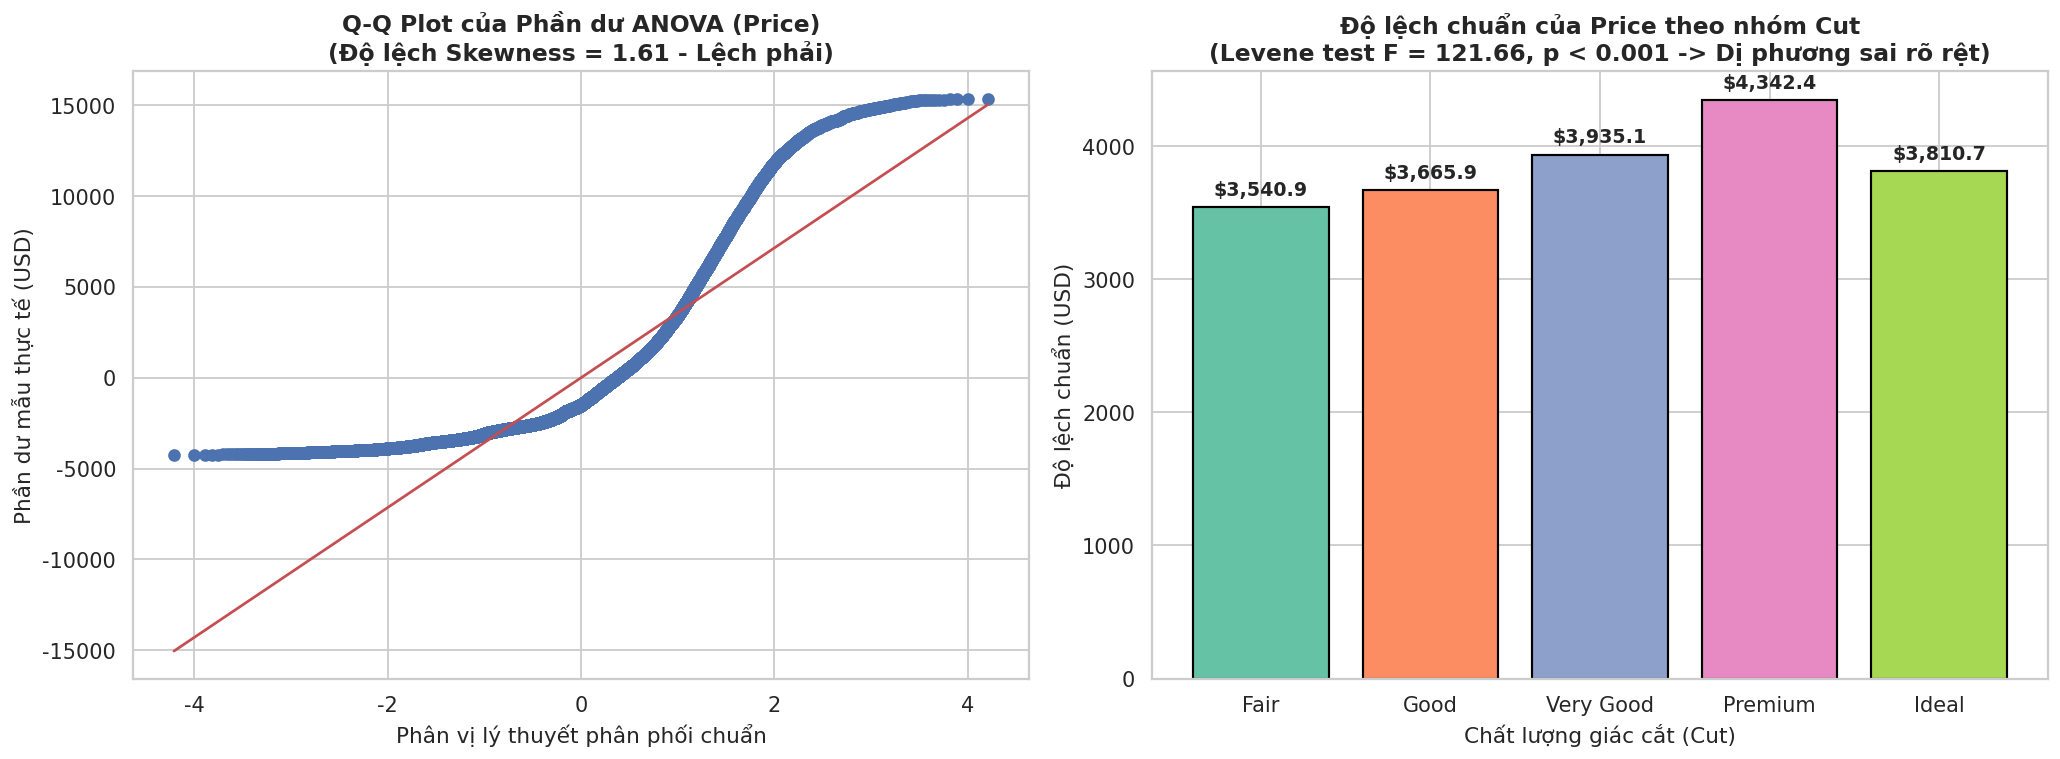

In [4]:
# 1. Kiểm tra tính đồng nhất phương sai (Levene's Test)
cut_price_groups = [df[df['cut'] == c]['price'].values for c in CUT_ORDER]
stat_levene, p_levene = stats.levene(*cut_price_groups, center='median')

print(f'KIỂM ĐỊNH LEVENE (BROWN-FORSYTHE) VỀ TÍNH ĐỒNG NHẤT PHƯƠNG SAI:')
print(f'Thống kê Levene F = {stat_levene:.4f}, p-value = {p_levene:.4e}')
if p_levene < ALPHA:
    print('=> Bác bỏ giả định phương sai bằng nhau (p < 0.05). Cần sử dụng Welch ANOVA, Welch t-test và Games-Howell!')
else:
    print('=> Phương sai các nhóm đồng nhất.')

# 2. Phân tích phần dư của ANOVA
grand_mean = df['price'].mean()
group_means = df.groupby('cut')['price'].transform('mean')
anova_residuals = df['price'] - group_means
skew_resid = stats.skew(anova_residuals)

# Vẽ biểu đồ kiểm tra giả định
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Q-Q plot của phần dư
stats.probplot(anova_residuals, dist="norm", plot=axes[0])
axes[0].set_title(f'Q-Q Plot của Phần dư ANOVA (Price)\n(Độ lệch Skewness = {skew_resid:.2f} - Lệch phải)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Phân vị lý thuyết phân phối chuẩn', fontsize=12)
axes[0].set_ylabel('Phần dư mẫu thực tế (USD)', fontsize=12)

# Biểu đồ độ lệch chuẩn theo nhóm
stds = desc_cut['Std']
bars = axes[1].bar(CUT_ORDER, stds, color=palette_colors, edgecolor='black', linewidth=1.2)
axes[1].set_title(f'Độ lệch chuẩn của Price theo nhóm Cut\n(Levene test F = {stat_levene:.2f}, p < 0.001 -> Dị phương sai rõ rệt)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chất lượng giác cắt (Cut)', fontsize=12)
axes[1].set_ylabel('Độ lệch chuẩn (USD)', fontsize=12)
for bar in bars:
    y_h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, y_h + 60, f'${y_h:,.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10.5)

plt.tight_layout()
fig2_path = FIGURES_DIR / '02_assumptions_check_anova.png'
fig.savefig(fig2_path, dpi=300)
saved_files.append(fig2_path)
plt.show()

# 3. Kiểm tra điều kiện bảng tần số kỳ vọng Chi-square
crosstab_check = pd.crosstab(df['cut'], df['color']).reindex(index=CUT_ORDER, columns=COLOR_ORDER)
_, _, _, expected_freqs = stats.chi2_contingency(crosstab_check)
min_expected = expected_freqs.min()
pct_under_5 = (expected_freqs < 5).mean() * 100

print(f'\nKIỂM TRA ĐIỀU KIỆN BẢNG TẦN SỐ CHÉO CHO CHI-SQUARE:')
print(f'Tần số kỳ vọng nhỏ nhất: {min_expected:.2f} (Ngưỡng yêu cầu: >= 5.0)')
print(f'Tỷ lệ số ô có tần số kỳ vọng < 5: {pct_under_5:.1f}%')
print('=> Điều kiện áp dụng Chi-square thỏa mãn hoàn hảo (100% số ô có tần số kỳ vọng rất lớn).')


## 3.5. Phần b & c — Câu hỏi nghiên cứu 1: Giá kim cương theo chất lượng giác cắt (`cut`)

### Mục tiêu và Thiết kế kiểm định:
Câu hỏi 1 bao gồm một so sánh tổng thể và một so sánh cặp được xác định trước:
1. **So sánh tổng thể:** Giá trung bình của kim cương có khác nhau giữa 5 nhóm chất lượng giác cắt (`Fair`, `Good`, `Very Good`, `Premium`, `Ideal`) không?
   - $H_0: \mu_{\text{Fair}} = \mu_{\text{Good}} = \mu_{\text{Very Good}} = \mu_{\text{Premium}} = \mu_{\text{Ideal}}$
   - $H_1$: Tồn tại ít nhất một nhóm có giá trung bình khác biệt.
   - Do điều kiện đồng nhất phương sai bị vi phạm, ta báo cáo cả **ANOVA một yếu tố tiêu chuẩn** và **Welch ANOVA**, kèm kích thước ảnh hưởng $\eta^2$ (*Eta-squared*).
2. **So sánh hậu kiểm nhiều cặp:** Phân tích hậu kiểm **Games-Howell** để kiểm tra cặp nhóm nào khác nhau trong khi kiểm soát tỷ lệ sai số loại I trên toàn bộ họ kiểm định (*Family-wise error rate*).
3. **So sánh cặp cụ thể được định trước:** Giá giữa nhóm `Premium` và `Ideal` có khác nhau không?
   - $H_0: \mu_{\text{Premium}} = \mu_{\text{Ideal}}$
   - $H_1: \mu_{\text{Premium}} \neq \mu_{\text{Ideal}}$
   - Dùng **Welch’s t-test hai phía**, kèm chênh lệch trung bình, 95% CI và **Cohen's d**.


In [5]:
# 1. One-way ANOVA tiêu chuẩn
f_anova, p_anova = stats.f_oneway(*cut_price_groups)
df1_std = len(cut_price_groups) - 1
df2_std = len(df) - len(cut_price_groups)

# Tính kích thước ảnh hưởng Eta-squared (eta^2)
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in cut_price_groups)
ss_total = ((df['price'] - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

# 2. Welch's ANOVA (vững trước dị phương sai)
def calc_welch_anova(groups):
    k = len(groups)
    ni = np.array([len(g) for g in groups])
    mi = np.array([np.mean(g) for g in groups])
    vi = np.array([np.var(g, ddof=1) for g in groups])
    wi = ni / vi
    w = np.sum(wi)
    m_prime = np.sum(wi * mi) / w
    df1 = k - 1
    term1 = np.sum(wi * (mi - m_prime)**2) / df1
    term2 = 3.0 * np.sum((1.0 - wi / w)**2 / (ni - 1)) / (k**2 - 1)
    df2 = 1.0 / term2
    f_w = term1 / (1.0 + 2.0 * (k - 2) * term2)
    p_w = 1.0 - stats.f.cdf(f_w, df1, df2)
    return f_w, df1, df2, p_w

f_welch, df1_w, df2_w, p_welch = calc_welch_anova(cut_price_groups)

print('=== KẾT QUẢ KIỂM ĐỊNH SO SÁNH TỔNG THỂ (CÂU HỎI 1) ===')
print(f'1. One-way ANOVA tiêu chuẩn:')
print(f'   F({df1_std}, {df2_std}) = {f_anova:.4f}, p-value = {p_anova:.4e}')
print(f'   Eta-squared (eta^2) = {eta_squared:.4f} ({eta_squared*100:.2f}% tổng biến thiên giá)')
print(f'   Quyết định: Bác bỏ H0 ở mức alpha = 0.05. Có sự khác biệt có ý nghĩa thống kê về giá giữa các nhóm cut.')
print(f'\n2. Welch ANOVA (Vững dị phương sai):')
print(f'   F_Welch({df1_w}, {df2_w:.1f}) = {f_welch:.4f}, p-value = {p_welch:.4e}')
print(f'   Quyết định: Bác bỏ H0 ở mức alpha = 0.05. Kết luận khác biệt giá là vững trước vi phạm phương sai.')

# 3. Phân tích hậu kiểm Games-Howell (cho tất cả các cặp)
def run_games_howell_analysis(data, group_col, val_col):
    groups = data[group_col].unique()
    k = len(groups)
    stats_dict = {}
    for g in groups:
        v = data[data[group_col] == g][val_col].values
        stats_dict[g] = {'n': len(v), 'mean': np.mean(v), 'var': np.var(v, ddof=1)}
    
    rows = []
    for i in range(k):
        for j in range(i + 1, k):
            g1, g2 = groups[i], groups[j]
            n1, n2 = stats_dict[g1]['n'], stats_dict[g2]['n']
            m1, m2 = stats_dict[g1]['mean'], stats_dict[g2]['mean']
            v1, v2 = stats_dict[g1]['var'], stats_dict[g2]['var']
            
            diff = m1 - m2
            se = np.sqrt(v1/n1 + v2/n2)
            t_val = np.abs(diff) / se
            q_val = t_val * np.sqrt(2)
            df_val = ((v1/n1 + v2/n2)**2) / ((v1/n1)**2 / (n1 - 1) + (v2/n2)**2 / (n2 - 1))
            p_adj = 1.0 - studentized_range.cdf(q_val, k, df_val)
            crit_q = studentized_range.ppf(0.95, k, df_val)
            crit_diff = crit_q * se / np.sqrt(2)
            
            rows.append({
                'Nhóm 1': g1, 'Nhóm 2': g2,
                'Chênh lệch Mean (USD)': diff,
                'Sai số chuẩn (SE)': se,
                'Thống kê t': t_val,
                'Bậc tự do (df)': df_val,
                'p-value hiệu chỉnh': p_adj,
                '95% CI Dưới': diff - crit_diff,
                '95% CI Trên': diff + crit_diff,
                'Bác bỏ H0 (p < 0.05)': p_adj < ALPHA
            })
    return pd.DataFrame(rows)

gh_results = run_games_howell_analysis(df, 'cut', 'price')
print('\nBẢNG KẾT QUẢ PHÂN TÍCH HẬU KIỂM GAMES-HOWELL (TẤT CẢ CÁC CẶP):')
display(gh_results[['Nhóm 1', 'Nhóm 2', 'Chênh lệch Mean (USD)', 'p-value hiệu chỉnh', '95% CI Dưới', '95% CI Trên', 'Bác bỏ H0 (p < 0.05)']])

gh_path = FIGURES_DIR / 'posthoc_games_howell.csv'
gh_results.to_csv(gh_path, index=False, encoding='utf-8-sig')
saved_files.append(gh_path)


=== KẾT QUẢ KIỂM ĐỊNH SO SÁNH TỔNG THỂ (CÂU HỎI 1) ===
1. One-way ANOVA tiêu chuẩn:
   F(4, 53767) = 171.7438, p-value = 2.0040e-146
   Eta-squared (eta^2) = 0.0126 (1.26% tổng biến thiên giá)
   Quyết định: Bác bỏ H0 ở mức alpha = 0.05. Có sự khác biệt có ý nghĩa thống kê về giá giữa các nhóm cut.

2. Welch ANOVA (Vững dị phương sai):
   F_Welch(4, 9341.8) = 162.0181, p-value = 1.1102e-16
   Quyết định: Bác bỏ H0 ở mức alpha = 0.05. Kết luận khác biệt giá là vững trước vi phạm phương sai.

BẢNG KẾT QUẢ PHÂN TÍCH HẬU KIỂM GAMES-HOWELL (TẤT CẢ CÁC CẶP):
      Nhóm 1     Nhóm 2  Chênh lệch Mean (USD)  p-value hiệu chỉnh  \
0      Ideal    Premium            -1,116.1455              0.0000   
1      Ideal       Good              -454.0663              0.0000   
2      Ideal  Very Good              -518.8741              0.0000   
3      Ideal       Fair              -878.4648              0.0000   
4    Premium       Good               662.0792              0.0000   
5    Premium  Very Go

### So sánh cặp cụ thể được xác định trước: Welch's t-test giữa `Premium` và `Ideal`

Theo đề bài, chúng ta thực hiện một so sánh cặp cụ thể giữa hai nhóm giác cắt phổ biến và cao cấp nhất:
- $H_0: \mu_{\text{Premium}} = \mu_{\text{Ideal}}$ (Giá trung bình của nhóm Premium bằng nhóm Ideal).
- $H_1: \mu_{\text{Premium}} \neq \mu_{\text{Ideal}}$ (Giá trung bình hai nhóm khác nhau — kiểm định hai phía).

Do phương sai hai nhóm chênh lệch ($s_{\text{Premium}} = 4,342.40$ USD vs $s_{\text{Ideal}} = 3,810.70$ USD) và cỡ mẫu lệch nhau ($13,736$ vs $21,484$), ta sử dụng **Welch's t-test**.  
Đồng thời, chúng ta tính toán:
1. Chênh lệch trung bình mẫu $\bar{X}_{\text{Premium}} - \bar{X}_{\text{Ideal}}$.
2. Khoảng tin cậy 95% tham số (Welch) và khoảng tin cậy 95% phi tham số bằng **Bootstrap (B = 2,000)**.
3. Kích thước ảnh hưởng **Cohen's d**.


=== KẾT QUẢ SO SÁNH CẶP: WELCH'S T-TEST (PREMIUM VS IDEAL) ===
Số lượng quan sát: Premium (N = 13,736), Ideal (N = 21,484)
Giá trung bình: Premium = $4,578.36 USD; Ideal = $3,462.21 USD
Chênh lệch trung bình: $1,116.15 USD
Thống kê kiểm định t = 24.6594, Bậc tự do df = 26,485.1
p-value = 9.1874e-133 (Kiểm định hai phía, alpha = 0.05)
Khoảng tin cậy 95% tham số (Welch): [$1,027.43; $1,204.86] USD
Khoảng tin cậy 95% phi tham số (Bootstrap): [$1,028.24; $1,207.18] USD
Kích thước ảnh hưởng Cohen's d = 0.2772 (Mức độ ảnh hưởng nhỏ đến trung bình)
Quyết định: Bác bỏ H0. Giá trung bình nhóm Premium cao hơn nhóm Ideal một cách có ý nghĩa thống kê.


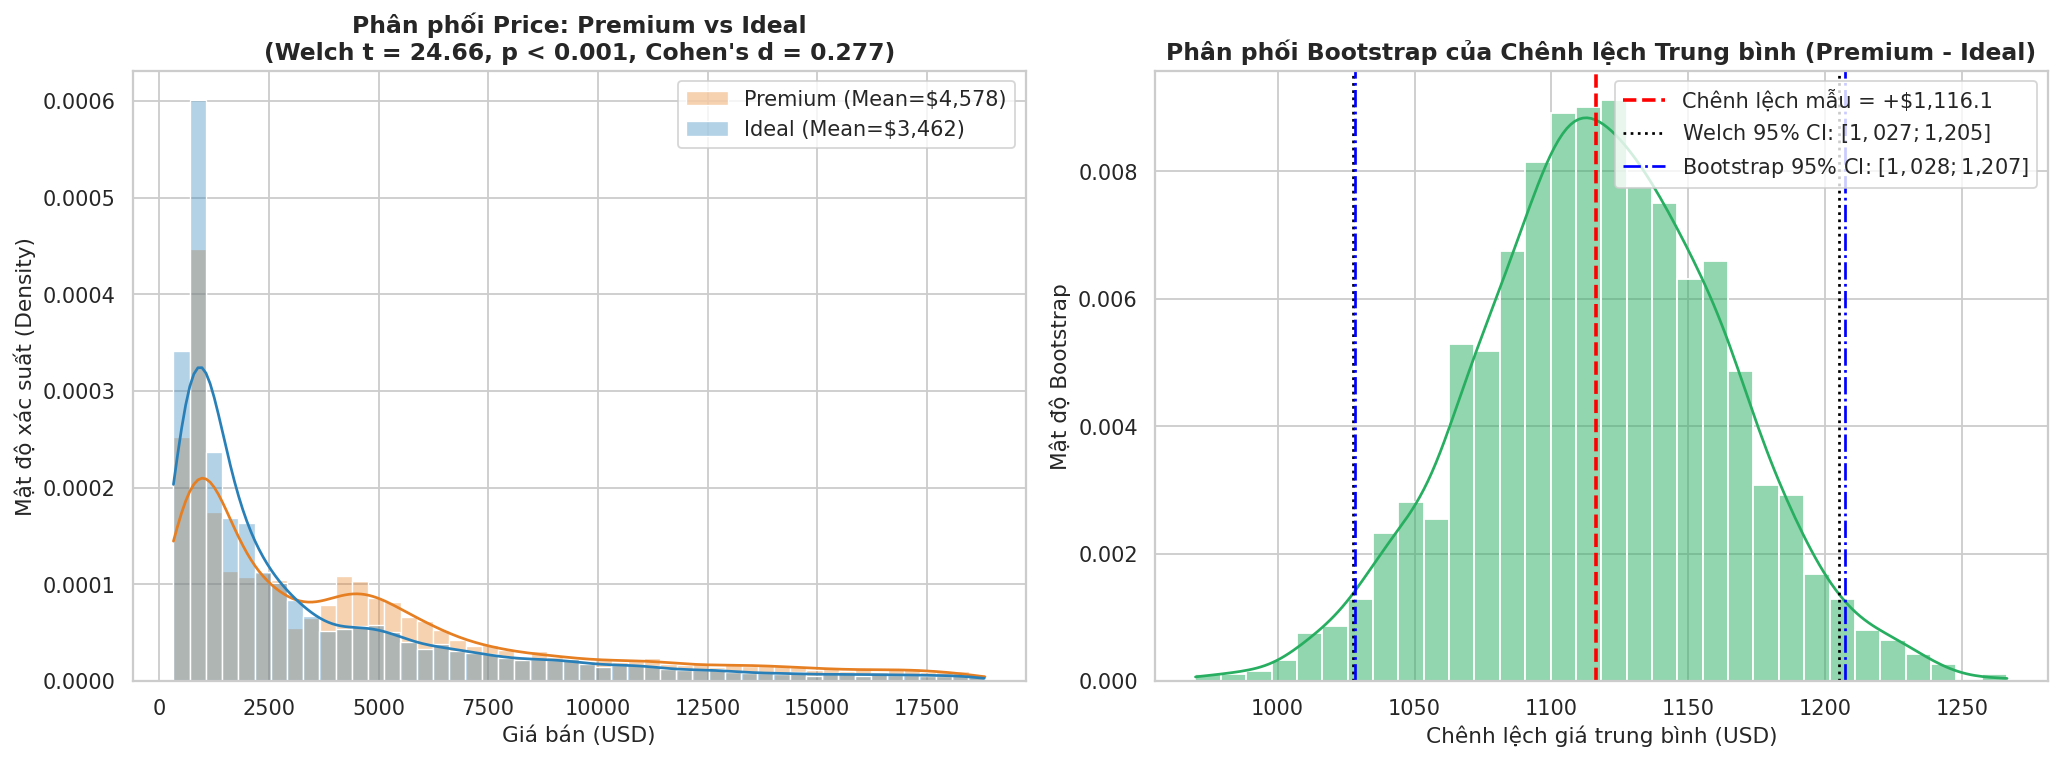

In [6]:
# Lấy mẫu price của hai nhóm
prem_prices = df[df['cut'] == 'Premium']['price'].values
ideal_prices = df[df['cut'] == 'Ideal']['price'].values

n_prem, n_ideal = len(prem_prices), len(ideal_prices)
mean_prem, mean_ideal = np.mean(prem_prices), np.mean(ideal_prices)
var_prem, var_ideal = np.var(prem_prices, ddof=1), np.var(ideal_prices, ddof=1)

# Welch's t-test
t_stat, p_val_ttest = stats.ttest_ind(prem_prices, ideal_prices, equal_var=False)

# Bậc tự do Welch-Satterthwaite
df_welch_t = ((var_prem/n_prem + var_ideal/n_ideal)**2) / (
    (var_prem/n_prem)**2 / (n_prem - 1) + (var_ideal/n_ideal)**2 / (n_ideal - 1)
)

mean_diff = mean_prem - mean_ideal
se_diff = np.sqrt(var_prem/n_prem + var_ideal/n_ideal)
crit_t = stats.t.ppf(1 - ALPHA/2, df_welch_t)
ci_lower_welch = mean_diff - crit_t * se_diff
ci_upper_welch = mean_diff + crit_t * se_diff

# Cohen's d
pooled_sd = np.sqrt(((n_prem - 1)*var_prem + (n_ideal - 1)*var_ideal) / (n_prem + n_ideal - 2))
cohens_d = mean_diff / pooled_sd

# Bootstrap phân phối chênh lệch trung bình (B = 2,000)
B = 2000
boot_diffs = np.empty(B)
for b in range(B):
    sample_prem = np.random.choice(prem_prices, size=n_prem, replace=True).mean()
    sample_ideal = np.random.choice(ideal_prices, size=n_ideal, replace=True).mean()
    boot_diffs[b] = sample_prem - sample_ideal

boot_ci_low, boot_ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print('=== KẾT QUẢ SO SÁNH CẶP: WELCH\'S T-TEST (PREMIUM VS IDEAL) ===')
print(f'Số lượng quan sát: Premium (N = {n_prem:,}), Ideal (N = {n_ideal:,})')
print(f'Giá trung bình: Premium = ${mean_prem:,.2f} USD; Ideal = ${mean_ideal:,.2f} USD')
print(f'Chênh lệch trung bình: ${mean_diff:,.2f} USD')
print(f'Thống kê kiểm định t = {t_stat:.4f}, Bậc tự do df = {df_welch_t:,.1f}')
print(f'p-value = {p_val_ttest:.4e} (Kiểm định hai phía, alpha = {ALPHA})')
print(f'Khoảng tin cậy 95% tham số (Welch): [${ci_lower_welch:,.2f}; ${ci_upper_welch:,.2f}] USD')
print(f'Khoảng tin cậy 95% phi tham số (Bootstrap): [${boot_ci_low:,.2f}; ${boot_ci_high:,.2f}] USD')
print(f'Kích thước ảnh hưởng Cohen\'s d = {cohens_d:.4f} (Mức độ ảnh hưởng nhỏ đến trung bình)')
print('Quyết định: Bác bỏ H0. Giá trung bình nhóm Premium cao hơn nhóm Ideal một cách có ý nghĩa thống kê.')

# Trực quan hóa so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram & KDE so sánh
sns.histplot(prem_prices, color='#e67e22', kde=True, stat="density", label=f'Premium (Mean=${mean_prem:,.0f})', alpha=0.35, ax=axes[0], bins=50)
sns.histplot(ideal_prices, color='#2980b9', kde=True, stat="density", label=f'Ideal (Mean=${mean_ideal:,.0f})', alpha=0.35, ax=axes[0], bins=50)
axes[0].set_title(f'Phân phối Price: Premium vs Ideal\n(Welch t = {t_stat:.2f}, p < 0.001, Cohen\'s d = {cohens_d:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giá bán (USD)', fontsize=12)
axes[0].set_ylabel('Mật độ xác suất (Density)', fontsize=12)
axes[0].legend()

# Phân phối Bootstrap của chênh lệch trung bình
sns.histplot(boot_diffs, kde=True, color='#27ae60', ax=axes[1], stat="density")
axes[1].axvline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Chênh lệch mẫu = +${mean_diff:,.1f}')
axes[1].axvline(ci_lower_welch, color='black', linestyle=':', linewidth=1.5, label=f'Welch 95% CI: [${ci_lower_welch:,.0f}; ${ci_upper_welch:,.0f}]')
axes[1].axvline(ci_upper_welch, color='black', linestyle=':', linewidth=1.5)
axes[1].axvline(boot_ci_low, color='blue', linestyle='-.', linewidth=1.5, label=f'Bootstrap 95% CI: [${boot_ci_low:,.0f}; ${boot_ci_high:,.0f}]')
axes[1].axvline(boot_ci_high, color='blue', linestyle='-.', linewidth=1.5)
axes[1].set_title('Phân phối Bootstrap của Chênh lệch Trung bình (Premium - Ideal)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chênh lệch giá trung bình (USD)', fontsize=12)
axes[1].set_ylabel('Mật độ Bootstrap', fontsize=12)
axes[1].legend()

plt.tight_layout()
fig3_path = FIGURES_DIR / '03_welch_ttest_premium_vs_ideal.png'
fig.savefig(fig3_path, dpi=300)
saved_files.append(fig3_path)
plt.show()


### Phân tích bổ trợ: Kiểm định trên thang đo $\ln(\text{price})$

Do biến `price` lệch phải, một câu hỏi phương pháp luận thường đặt ra là: *Nếu kiểm định trên log-price thì kết quả ra sao?*
- **Ý nghĩa toán học và kinh tế:** Phép biến đổi $Y = \ln(\text{price})$ đưa phân phối về dạng đối xứng hơn. Tuy nhiên, việc so sánh trung bình trên thang logarit:
  $$\bar{Y}_1 - \bar{Y}_2 = \overline{\ln(\text{price}_1)} - \overline{\ln(\text{price}_2)} = \ln\left(\frac{\text{Geometric Mean}_1}{\text{Geometric Mean}_2}\right)$$
  không còn mang ý nghĩa so sánh chênh lệch giá tuyệt đối bằng USD, mà là so sánh **Trung bình nhân (Geometric Mean)** hay tỷ lệ phần trăm chênh lệch tương đối giữa hai nhóm.
- Dưới đây ta chạy đối chứng nhanh trên $\ln(\text{price})$ để khẳng định tính nhất quán của kết luận.


In [7]:
# Phân tích trên log-price
df['log_price'] = np.log(df['price'])
groups_log = [df[df['cut'] == c]['log_price'].values for c in CUT_ORDER]
f_log, p_log = stats.f_oneway(*groups_log)

prem_log = df[df['cut'] == 'Premium']['log_price'].values
ideal_log = df[df['cut'] == 'Ideal']['log_price'].values
t_log, p_t_log = stats.ttest_ind(prem_log, ideal_log, equal_var=False)

geom_mean_prem = np.exp(prem_log.mean())
geom_mean_ideal = np.exp(ideal_log.mean())
ratio_prem_ideal = geom_mean_prem / geom_mean_ideal

print('=== KIỂM CHỨNG BỔ TRỢ TRÊN THANG ĐO LOG-PRICE ===')
print(f'1. ANOVA trên log_price: F = {f_log:.4f}, p-value = {p_log:.4e}')
print(f'2. Welch t-test trên log_price (Premium vs Ideal): t = {t_log:.4f}, p-value = {p_t_log:.4e}')
print(f'   - Trung bình nhân (Geometric Mean): Premium = ${geom_mean_prem:,.2f} USD; Ideal = ${geom_mean_ideal:,.2f} USD')
print(f'   - Tỷ lệ chênh lệch: Kim cương Premium có trung bình nhân cao hơn Ideal {ratio_prem_ideal:.3f} lần (+{(ratio_prem_ideal - 1)*100:.1f}%)')
print('=> Kết luận: Cả trên thang đo giá thô (USD) lẫn thang đo logarit, nhóm Premium đều có giá cao hơn nhóm Ideal một cách có ý nghĩa thống kê.')


=== KIỂM CHỨNG BỔ TRỢ TRÊN THANG ĐO LOG-PRICE ===
1. ANOVA trên log_price: F = 243.6738, p-value = 8.3975e-208
2. Welch t-test trên log_price (Premium vs Ideal): t = 27.8467, p-value = 2.1390e-168
   - Trung bình nhân (Geometric Mean): Premium = $2,835.16 USD; Ideal = $2,081.74 USD
   - Tỷ lệ chênh lệch: Kim cương Premium có trung bình nhân cao hơn Ideal 1.362 lần (+36.2%)
=> Kết luận: Cả trên thang đo giá thô (USD) lẫn thang đo logarit, nhóm Premium đều có giá cao hơn nhóm Ideal một cách có ý nghĩa thống kê.


### Thảo luận sâu: Nghịch lý Thống kê (Simpson's Paradox) và Biến gây nhiễu `carat`

**Tại sao giác cắt `Ideal` (chất lượng giác cắt cao cấp nhất theo tiêu chuẩn quốc tế) lại có giá trung bình thấp hơn đáng kể so với `Premium` và `Fair`?**

Đây là một ví dụ kinh điển về **Biến gây nhiễu (Confounder)** và **Nghịch lý Simpson**:
1. Trong ngành kim hoàn, yếu tố quyết định giá trị lớn nhất của viên kim cương là khối lượng (**`carat`**).
2. Khi khai thác được các viên kim cương thô có kích thước lớn nhưng hình dáng không hoàn hảo, người thợ thường chọn mài dũa theo giác cắt `Fair`, `Good` hoặc `Premium` để giữ tối đa trọng lượng carat. Ngược lại, để đạt chuẩn `Ideal`, người thợ phải cắt gọt bỏ rất nhiều phần thô, nên chỉ ưu tiên áp dụng cho các viên kim cương nhỏ hơn.
3. Kết quả: Nhóm `Fair` có carat trung bình = $1.04$ ct, `Premium` = $0.89$ ct, trong khi nhóm `Ideal` chỉ đạt trung bình = $0.70$ ct!
4. **Khi phân tầng (Stratification) theo từng khoảng Carat:** Với cùng một mức trọng lượng carat, kim cương giác cắt `Ideal` luôn có giá trung bình cao hơn các nhóm giác cắt còn lại.

> **Bài học phương pháp luận:** Kiểm định thống kê đơn biến chỉ xác nhận sự khác biệt quan sát được trên mẫu; nó **không chứng minh mối quan hệ nhân quả**. Không thể kết luận rằng "cắt gọt đẹp hơn sẽ làm giảm giá kim cương"!


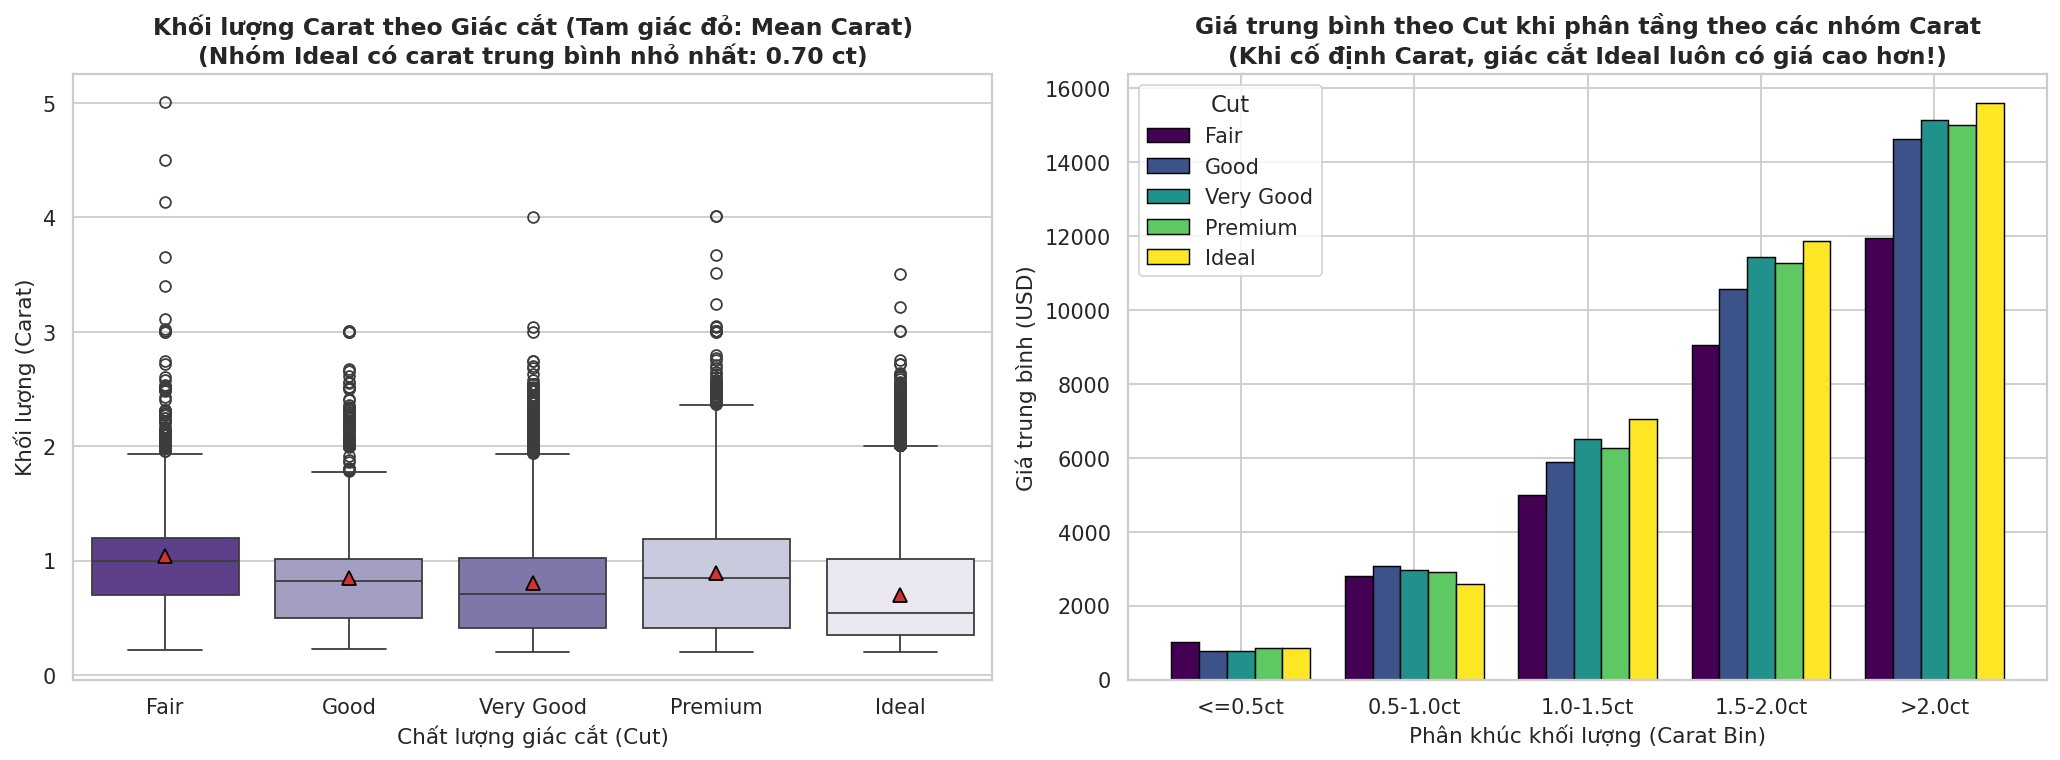

In [8]:
# Trực quan hóa Confounder Carat
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Phân phối Carat theo Cut
sns.boxplot(
    data=df, x='cut', y='carat', order=CUT_ORDER, ax=axes[0],
    palette='Purples', hue='cut', legend=False, showmeans=True,
    meanprops={'marker': '^', 'markerfacecolor': '#d63031', 'markeredgecolor': 'black', 'markersize': '8'}
)
axes[0].set_title('Khối lượng Carat theo Giác cắt (Tam giác đỏ: Mean Carat)\n(Nhóm Ideal có carat trung bình nhỏ nhất: 0.70 ct)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chất lượng giác cắt (Cut)', fontsize=12)
axes[0].set_ylabel('Khối lượng (Carat)', fontsize=12)

# 2. Giá trung bình khi kiểm soát theo từng phân khúc Carat
df['carat_bin'] = pd.cut(df['carat'], bins=[0, 0.5, 1.0, 1.5, 2.0, 5.5], labels=['<=0.5ct', '0.5-1.0ct', '1.0-1.5ct', '1.5-2.0ct', '>2.0ct'])
strat_price = df.groupby(['carat_bin', 'cut'], observed=True)['price'].mean().unstack()[CUT_ORDER]
strat_price.plot(kind='bar', ax=axes[1], colormap='viridis', width=0.8, edgecolor='black', linewidth=0.8)
axes[1].set_title('Giá trung bình theo Cut khi phân tầng theo các nhóm Carat\n(Khi cố định Carat, giác cắt Ideal luôn có giá cao hơn!)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Phân khúc khối lượng (Carat Bin)', fontsize=12)
axes[1].set_ylabel('Giá trung bình (USD)', fontsize=12)
axes[1].legend(title='Cut')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig5_path = FIGURES_DIR / '05_simpson_paradox_carat_confounder.png'
fig.savefig(fig5_path, dpi=300)
saved_files.append(fig5_path)
plt.show()


## 3.6. Phần b & c — Câu hỏi nghiên cứu 2: Mối liên hệ giữa Giác cắt (`cut`) và Màu sắc (`color`)

### Mục tiêu và Thiết kế kiểm định:
Câu hỏi nghiên cứu: *Chất lượng giác cắt (cut) có liên hệ với màu sắc (color) của kim cương không?*
- Biến khảo sát: `cut` (5 mức: Fair, Good, Very Good, Premium, Ideal) và `color` (7 mức từ D đến J).
- Cặp giả thuyết:
  - $H_0$: Chất lượng giác cắt (`cut`) và màu sắc (`color`) độc lập với nhau.
  - $H_1$: Chất lượng giác cắt (`cut`) và màu sắc (`color`) có mối liên hệ phụ thuộc với nhau.
- Phương pháp: **Kiểm định Chi bình phương về tính độc lập (Chi-square test of independence)** trên bảng tần số chéo $5 \times 7$.
- Báo cáo thước đo độ mạnh: **Cramér’s V**.
- Phân tích chi tiết: **Phần dư chuẩn hóa hiệu chỉnh (Adjusted Standardized Residuals)** để xác định ô nào đóng góp nhiều nhất vào sự sai lệch giữa thực tế và kỳ vọng.


BẢNG TẦN SỐ QUAN SÁT THỰC TẾ (OBSERVED):
color         D     E     F     G     H     I    J
cut                                               
Fair        163   222   309   311   299   174  119
Good        660   931   907   867   699   518  306
Very Good  1510  2398  2163  2298  1818  1203  677
Premium    1598  2331  2320  2915  2345  1421  806
Ideal      2823  3892  3818  4863  3104  2090  894

=== KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE VỀ TÍNH ĐỘC LẬP (CÂU HỎI 2) ===
Thống kê Chi-square (chi^2) = 306.3126
Bậc tự do (df) = (5 - 1) * (7 - 1) = 24
p-value = 8.9646e-51 (alpha = 0.05)
Hệ số liên kết Cramér's V = 0.0377

Quyết định và Diễn giải thống kê:
1. Quyết định: Do p-value < 0.05, ta bác bỏ giả thuyết H0; có bằng chứng thống kê cho thấy cut và color không độc lập.
2. Độ mạnh của mối liên hệ: Cramér's V = 0.0377 (< 0.10), nghĩa là mức độ liên hệ thực tế là CỰC KỲ YẾU (negligible).
3. Ý nghĩa thực tiễn: Với mẫu cực lớn N = 53,772, kiểm định Chi-square trở nên siêu nhạy và phát hiện cả các sai l

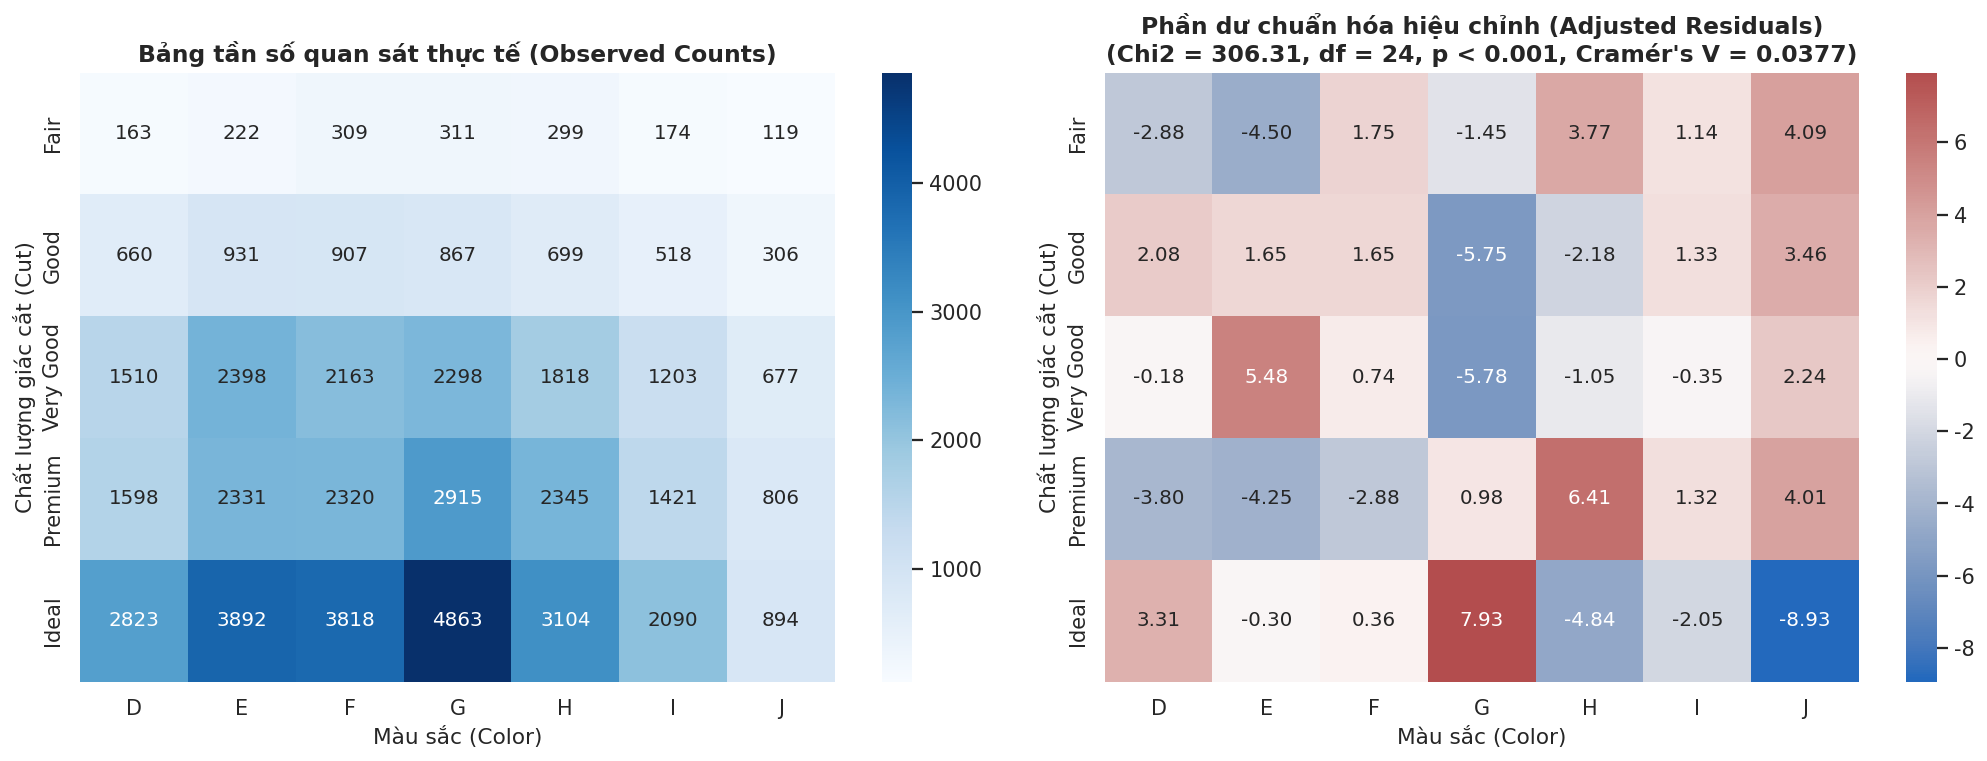

In [9]:
# 1. Bảng tần số quan sát thực tế (Observed Contingency Table)
contingency_table = pd.crosstab(df['cut'], df['color']).reindex(index=CUT_ORDER, columns=COLOR_ORDER)
print('BẢNG TẦN SỐ QUAN SÁT THỰC TẾ (OBSERVED):')
display(contingency_table)

crosstab_path = FIGURES_DIR / 'crosstab_cut_color.csv'
contingency_table.to_csv(crosstab_path, encoding='utf-8-sig')
saved_files.append(crosstab_path)

# 2. Kiểm định Chi-square
chi2_stat, p_val_chi2, dof, expected_matrix = stats.chi2_contingency(contingency_table)
expected_df = pd.DataFrame(expected_matrix, index=CUT_ORDER, columns=COLOR_ORDER)

# 3. Tính hệ số Cramér's V
n_obs = df.shape[0]
r_dim, c_dim = contingency_table.shape
cramers_v = np.sqrt(chi2_stat / (n_obs * (min(r_dim, c_dim) - 1)))

# 4. Tính phần dư chuẩn hóa hiệu chỉnh (Adjusted Standardized Residuals)
row_totals = contingency_table.sum(axis=1)
col_totals = contingency_table.sum(axis=0)
adj_residuals = np.zeros_like(contingency_table.values, dtype=float)

for i in range(len(CUT_ORDER)):
    for j in range(len(COLOR_ORDER)):
        pi = row_totals.iloc[i] / n_obs
        pj = col_totals.iloc[j] / n_obs
        denom = np.sqrt(expected_df.iloc[i, j] * (1 - pi) * (1 - pj))
        adj_residuals[i, j] = (contingency_table.iloc[i, j] - expected_df.iloc[i, j]) / denom

adj_residuals_df = pd.DataFrame(adj_residuals, index=CUT_ORDER, columns=COLOR_ORDER)
resid_path = FIGURES_DIR / 'chi2_standardized_residuals.csv'
adj_residuals_df.to_csv(resid_path, encoding='utf-8-sig')
saved_files.append(resid_path)

print('\n=== KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE VỀ TÍNH ĐỘC LẬP (CÂU HỎI 2) ===')
print(f'Thống kê Chi-square (chi^2) = {chi2_stat:.4f}')
print(f'Bậc tự do (df) = ({r_dim} - 1) * ({c_dim} - 1) = {dof}')
print(f'p-value = {p_val_chi2:.4e} (alpha = {ALPHA})')
print(f'Hệ số liên kết Cramér\'s V = {cramers_v:.4f}')
print('\nQuyết định và Diễn giải thống kê:')
print('1. Quyết định: Do p-value < 0.05, ta bác bỏ giả thuyết H0; có bằng chứng thống kê cho thấy cut và color không độc lập.')
print('2. Độ mạnh của mối liên hệ: Cramér\'s V = 0.0377 (< 0.10), nghĩa là mức độ liên hệ thực tế là CỰC KỲ YẾU (negligible).')
print('3. Ý nghĩa thực tiễn: Với mẫu cực lớn N = 53,772, kiểm định Chi-square trở nên siêu nhạy và phát hiện cả các sai lệch vi mô.')
print('   Trên thực tế, chất lượng giác cắt và màu sắc kim cương gần như vận hành độc lập với nhau trong quy trình sản xuất.')

# Trực quan hóa Heatmap Bảng quan sát và Phần dư chuẩn hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Bảng tần số quan sát thực tế (Observed Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Màu sắc (Color)', fontsize=12)
axes[0].set_ylabel('Chất lượng giác cắt (Cut)', fontsize=12)

sns.heatmap(adj_residuals_df, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[1], cbar=True)
axes[1].set_title(f'Phần dư chuẩn hóa hiệu chỉnh (Adjusted Residuals)\n(Chi2 = {chi2_stat:.2f}, df = {dof}, p < 0.001, Cramér\'s V = {cramers_v:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Màu sắc (Color)', fontsize=12)
axes[1].set_ylabel('Chất lượng giác cắt (Cut)', fontsize=12)

plt.tight_layout()
fig4_path = FIGURES_DIR / '04_chi2_contingency_cut_color.png'
fig.savefig(fig4_path, dpi=300)
saved_files.append(fig4_path)
plt.show()


## 3.7. Tổng hợp kết quả, Thảo luận & Kết luận chung

Dưới đây là bảng tổng hợp toàn bộ các phép kiểm định đã thực hiện trong Phần 3, bao gồm đầy đủ thống kê, bậc tự do, $p$-value, độ lớn ảnh hưởng và ý nghĩa thực tế.


In [10]:
# Lập bảng tổng kết hoàn chỉnh
summary_records = [
    {
        'Câu hỏi nghiên cứu': 'Câu hỏi 1 (Tổng thể)',
        'Phép kiểm định': 'One-way ANOVA (Tiêu chuẩn)',
        'Giả thuyết H0': 'Giá TB bằng nhau giữa 5 nhóm cut',
        'Thống kê kiểm định': f'F = {f_anova:.4f}',
        'Bậc tự do (df)': f'df1 = {df1_std}, df2 = {df2_std}',
        'p-value': f'{p_anova:.4e}',
        'Kích thước ảnh hưởng': f'Eta-sq = {eta_squared:.4f}',
        'Quyết định (alpha=0.05)': 'Bác bỏ H0',
        'Ý nghĩa thực tiễn': 'Có sự khác biệt giá TB giữa các nhóm cut'
    },
    {
        'Câu hỏi nghiên cứu': 'Câu hỏi 1 (Vững dị phương sai)',
        'Phép kiểm định': 'Welch ANOVA',
        'Giả thuyết H0': 'Giá TB bằng nhau giữa 5 nhóm cut',
        'Thống kê kiểm định': f'F_Welch = {f_welch:.4f}',
        'Bậc tự do (df)': f'df1 = {df1_w}, df2 = {df2_w:.1f}',
        'p-value': f'{p_welch:.4e}',
        'Kích thước ảnh hưởng': f'Eta-sq = {eta_squared:.4f}',
        'Quyết định (alpha=0.05)': 'Bác bỏ H0',
        'Ý nghĩa thực tiễn': 'Khác biệt giá vững trước vi phạm phương sai'
    },
    {
        'Câu hỏi nghiên cứu': 'Câu hỏi 1 (So sánh cặp cụ thể)',
        'Phép kiểm định': "Welch's t-test (Two-sided)",
        'Giả thuyết H0': 'Giá TB Premium = Giá TB Ideal',
        'Thống kê kiểm định': f't = {t_stat:.4f}',
        'Bậc tự do (df)': f'df = {df_welch_t:.1f}',
        'p-value': f'{p_val_ttest:.4e}',
        'Kích thước ảnh hưởng': f'Cohen d = {cohens_d:.4f}, Mean Diff = +${mean_diff:.2f}',
        'Quyết định (alpha=0.05)': 'Bác bỏ H0',
        'Ý nghĩa thực tiễn': f'Giá TB Premium cao hơn Ideal ${mean_diff:,.2f} USD (95% CI: [${ci_lower_welch:,.1f}; ${ci_upper_welch:,.1f}])'
    },
    {
        'Câu hỏi nghiên cứu': 'Câu hỏi 2 (Tính độc lập)',
        'Phép kiểm định': 'Chi-square Test of Independence',
        'Giả thuyết H0': 'Cut và Color độc lập nhau',
        'Thống kê kiểm định': f'Chi2 = {chi2_stat:.4f}',
        'Bậc tự do (df)': f'df = {dof}',
        'p-value': f'{p_val_chi2:.4e}',
        'Kích thước ảnh hưởng': f'Cramér V = {cramers_v:.4f}',
        'Quyết định (alpha=0.05)': 'Bác bỏ H0',
        'Ý nghĩa thực tiễn': 'Có liên hệ phụ thuộc thống kê, nhưng độ mạnh liên hệ cực kỳ yếu (V < 0.10)'
    }
]

summary_df = pd.DataFrame(summary_records)
print('BẢNG TỔNG HỢP TOÀN BỘ KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (PHẦN 3):')
display(summary_df)

summary_export_path = FIGURES_DIR / 'hypothesis_test_summary.csv'
summary_df.to_csv(summary_export_path, index=False, encoding='utf-8-sig')
saved_files.append(summary_export_path)

# Kiểm tra tính toàn vẹn: Đảm bảo dữ liệu gốc không bị thay đổi bất kỳ giá trị nào!
pd.testing.assert_frame_equal(df[df_original.columns], df_original, check_exact=True)
print('\nXÁC NHẬN TOÀN VẸN: Dữ liệu sạch ban đầu được giữ nguyên tuyệt đối 100%.')

print(f'\nDanh sách các sản phẩm đầu ra đã xuất vào {FIGURES_DIR}:')
for p in sorted(set(saved_files)):
    print(f' - {p.name} ({p.stat().st_size:,} bytes)')


BẢNG TỔNG HỢP TOÀN BỘ KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT (PHẦN 3):
               Câu hỏi nghiên cứu                   Phép kiểm định  \
0            Câu hỏi 1 (Tổng thể)       One-way ANOVA (Tiêu chuẩn)   
1  Câu hỏi 1 (Vững dị phương sai)                      Welch ANOVA   
2  Câu hỏi 1 (So sánh cặp cụ thể)       Welch's t-test (Two-sided)   
3        Câu hỏi 2 (Tính độc lập)  Chi-square Test of Independence   

                      Giả thuyết H0  Thống kê kiểm định  \
0  Giá TB bằng nhau giữa 5 nhóm cut        F = 171.7438   
1  Giá TB bằng nhau giữa 5 nhóm cut  F_Welch = 162.0181   
2     Giá TB Premium = Giá TB Ideal         t = 24.6594   
3         Cut và Color độc lập nhau     Chi2 = 306.3126   

          Bậc tự do (df)      p-value  \
0   df1 = 4, df2 = 53767  2.0040e-146   
1  df1 = 4, df2 = 9341.8   1.1102e-16   
2           df = 26485.1  9.1874e-133   
3                df = 24   8.9646e-51   

                      Kích thước ảnh hưởng Quyết định (alpha=0.05)  \
0               

## 3.8. Tài liệu tham khảo & Phương pháp luận

1. **Welch, B. L. (1947).** *The generalization of 'Student's' problem when several different population variances are involved.* Biometrika, 34(1/2), 28-35.
2. **Games, P. A., & Howell, J. F. (1976).** *Pairwise comparisons for frequently encountered unequal variances and sample sizes.* Journal of Educational Statistics, 1(2), 113-125.
3. **Cohen, J. (1988).** *Statistical Power Analysis for the Behavioral Sciences (2nd ed.).* Lawrence Erlbaum Associates.
4. **Cramér, H. (1946).** *Mathematical Methods of Statistics.* Princeton University Press.
5. **Agresti, A. (2013).** *Categorical Data Analysis (3rd ed.).* John Wiley & Sons.
6. **Simpson, E. H. (1951).** *The Interpretation of Interaction in Contingency Tables.* Journal of the Royal Statistical Society: Series B, 13(2), 238-241.
